In [1]:
from io import StringIO
import matplotlib.pyplot as plt
import pandas as pd
import os,glob
os.chdir('F:\\geodata\\river_runoff_obs\\ood_validation')
os.chdir('F:\\geodata\\river_runoff_obs\\ood_validation')


In [2]:
# Raw data as a string
data = """
abbre,ssp126,ssp245,ssp370,ssp585
hsg, 	2020,	2019,	2021,	2021
dsk,	2026,	2027,	2029,	2032
xhl,	2042,	2053,	2055,	2049
slglk,	2042,	2054,	2056,	2058
kq,		2055,	2077,	2074,	2078
wlwt,	2064,	2077,	2093,	2084
tgzlk,	2069,	2080,	2094,	2094
"""

# Use StringIO to simulate a file
data_io = StringIO(data)

# Read the data into a DataFrame
peak_water_df = pd.read_csv(data_io,index_col=0)

# Display the DataFrame
print(peak_water_df)

       ssp126  ssp245  ssp370  ssp585
abbre                                
hsg      2020    2019    2021    2021
dsk      2026    2027    2029    2032
xhl      2042    2053    2055    2049
slglk    2042    2054    2056    2058
kq       2055    2077    2074    2078
wlwt     2064    2077    2093    2084
tgzlk    2069    2080    2094    2094


In [3]:
colors = ['#00008B', '#FFA500', '#FF0000', '#B22222']  # Define colors for the 4 scenarios

In [4]:
file_name_list = ['1_hsg_imputMF','2_dsk_imputMF','3_xhl_imputMF','4_slglk_imputMF','5_kq_imputMF','6_wlwt_imputMF','7_tgzlk_imputMF']

In [5]:
import pymannkendall as mk

hsg ssp126
hsg ssp245
hsg ssp370
hsg ssp585
dsk ssp126
dsk ssp245
dsk ssp370
dsk ssp585
xhl ssp126
xhl ssp245
xhl ssp370
xhl ssp585
slglk ssp126
slglk ssp245
slglk ssp370
slglk ssp585
kq ssp126
kq ssp245
kq ssp370
kq ssp585
wlwt ssp126
wlwt ssp245
wlwt ssp370
wlwt ssp585
tgzlk ssp126
tgzlk ssp245
tgzlk ssp370
tgzlk ssp585


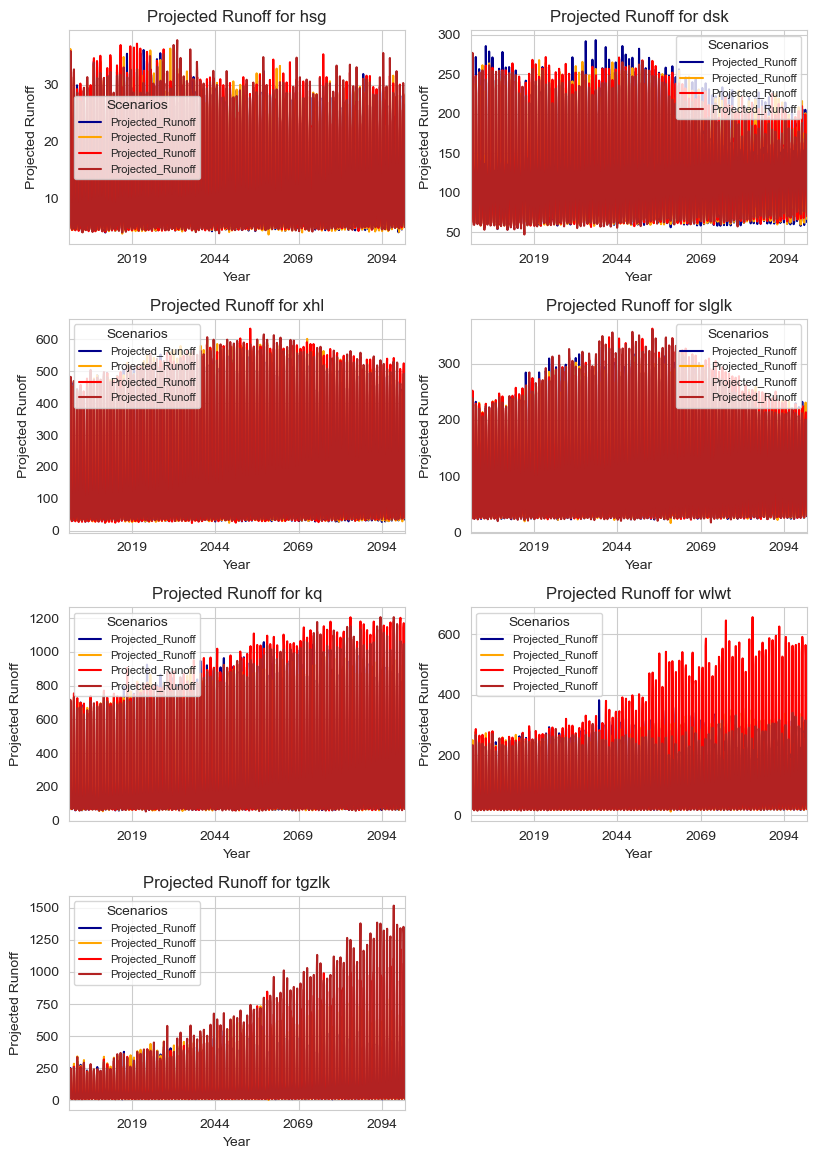

In [6]:
# Create a figure with 7 subplots
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=( 8.27 , 11.69))  # Adjust figsize as needed
axes = axes.flatten()  # Flatten for easier indexing
# Remove the last unused subplot (if 7 subfigures)
fig.delaxes(axes[-1])

for i, file_name in enumerate(file_name_list):
    abbre = file_name.split('_')[1]
    ax = axes[i]  # Get the current subplot axis

    for j, scenario in enumerate(['ssp126', 'ssp245', 'ssp370', 'ssp585']):
        print(abbre, scenario)
        csv_mon_files = glob.glob(f'{file_name}*{scenario}*mon*_project.csv')
        csv_mon_files = [item for item in csv_mon_files if 'multi-model' not in item]

        mon_df_list = [pd.read_csv(file, index_col=0) for file in csv_mon_files]
        for mon_df in mon_df_list:
            mon_df.index = pd.to_datetime(mon_df.index)
        annual_df_list = [df.resample('YE').mean() for df in mon_df_list]
        annaul_concatenated_df = pd.concat(annual_df_list, axis=0, keys=range(len(annual_df_list)))

        annual_std_dev = annaul_concatenated_df.groupby(level=1).std()

        # Concatenate DataFrames along a new axis and calculate standard deviation row-wise
        concatenated_df = pd.concat(mon_df_list, axis=0, keys=range(len(mon_df_list)))

        # Calculate standard deviation across the concatenated DataFrame
        std_dev_df = concatenated_df.groupby(level=1).std()
        std_dev_df.index = pd.to_datetime(std_dev_df.index)
        # Add a 'year' column for grouping
        std_dev_df['year'] = std_dev_df.index.year

        mean_df = concatenated_df.groupby(level=1).mean()
        mean_df.index = pd.to_datetime(mean_df.index)
        annual_mean_df = mean_df.resample('YE').mean()
        annual_mean_df.index = annual_mean_df.index.year
        annual_std_dev.index = annual_std_dev.index.year

        # Plot the mean 'Projected_Runoff' for the current scenario with color

        mean_df['Projected_Runoff'].plot(ax=ax, color=colors[j])
        # ax.plot(
        #     # mean_df.index,
        #     mean_df['Projected_Runoff'],
        #     label=scenario,
        #     color=colors[j]  # Set the color based on the scenario index
        # )
        # ax.fill_between(
        #     annual_std_dev.index,
        #     -annual_std_dev['Projected_Runoff'] + annual_mean_df['Projected_Runoff'],
        #     annual_std_dev['Projected_Runoff'] + annual_mean_df['Projected_Runoff'],
        #     color=colors[j],  # Set the color based on the scenario index
        #     alpha=0.3,
        # )

    # Customize the subplot
    ax.set_title(f'Projected Runoff for {abbre}')
    # ax.set_xlim(2000, 2100)
    ax.set_xlabel('Year')
    ax.set_ylabel('Projected Runoff')
    ax.legend(title='Scenarios', fontsize=8)
    ax.grid(True)

# Adjust layout
plt.tight_layout()
plt.show()

hsg ssp126 -0.04237687260637146 -0.04237687260637146
hsg ssp245 -0.02382040532024965 -0.02382040532024965
hsg ssp370 0.04743643621442328 0.04743643621442328
hsg ssp585 0.17260492096802205 0.17260492096802205
dsk ssp126 -0.04332645994165052 -0.04332645994165052
dsk ssp245 -0.015419496833195545 -0.015419496833195545
dsk ssp370 0.010916765060707379 0.010916765060707379
dsk ssp585 0.027037253444545772 0.027037253444545772
xhl ssp126 0.10045612898602418 0.10045612898602418
xhl ssp245 0.20965510876374993 0.20965510876374993
xhl ssp370 0.34151313817040285 0.34151313817040285
xhl ssp585 0.40358964746504844 0.40358964746504844
slglk ssp126 0.038057651659966885 0.038057651659966885
slglk ssp245 0.08169136965864321 0.08169136965864321
slglk ssp370 0.12336821712987667 0.12336821712987667
slglk ssp585 0.1776502996577325 0.1776502996577325
kq ssp126 0.18278312491163162 0.18278312491163162
kq ssp245 0.43373637221210104 0.43373637221210104
kq ssp370 0.7967251796020312 0.7967251796020312
kq ssp585 0.85

C:\Users\HP\AppData\Local\Temp\ipykernel_154816\2836437580.py:126: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


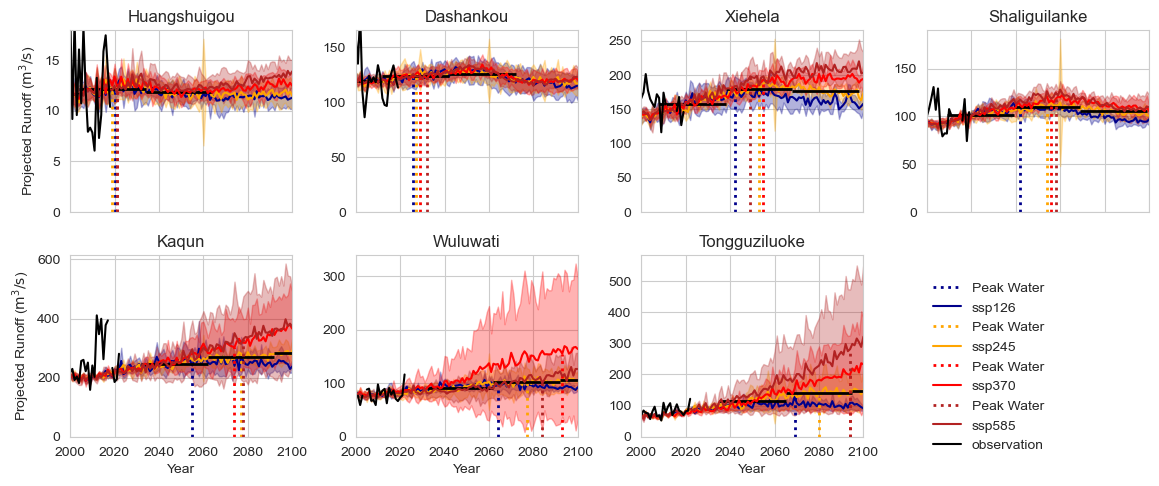

In [7]:
station_names = ['Huangshuigou', 'Dashankou', 'Xiehela', 'Shaliguilanke', 'Kaqun', 'Wuluwati', 'Tongguziluoke']

# Create a figure with 7 subplots
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(11.69, 8.27 * 0.6))  # Adjust figsize as needed
axes = axes.flatten()  # Flatten for easier indexing
# Remove the last unused subplot (if 7 subfigures)
fig.delaxes(axes[-1])

for i, file_name in enumerate(file_name_list):
    abbre = file_name.split('_')[1]
    ax = axes[i]  # Get the current subplot axis

    for j, scenario in enumerate(['ssp126', 'ssp245', 'ssp370', 'ssp585']):
        csv_mon_files = glob.glob(f'{file_name}*{scenario}*mon_256_16_project.csv')
        csv_mon_files = [item for item in csv_mon_files if 'multi-model' not in item]

        mon_df_list = [pd.read_csv(file, index_col=0) for file in csv_mon_files]
        for mon_df in mon_df_list:
            mon_df.index = pd.to_datetime(mon_df.index)
        annual_df_list = [df.resample('YE').mean() for df in mon_df_list]
        annaul_concatenated_df = pd.concat(annual_df_list, axis=0, keys=range(len(annual_df_list)))

        annual_std_dev = annaul_concatenated_df.groupby(level=1).std()

        # Concatenate DataFrames along a new axis and calculate standard deviation row-wise
        concatenated_df = pd.concat(mon_df_list, axis=0, keys=range(len(mon_df_list)))

        # Calculate standard deviation across the concatenated DataFrame
        std_dev_df = concatenated_df.groupby(level=1).std()
        std_dev_df.index = pd.to_datetime(std_dev_df.index)
        # Add a 'year' column for grouping
        std_dev_df['year'] = std_dev_df.index.year

        mean_df = concatenated_df.groupby(level=1).mean()
        mean_df.index = pd.to_datetime(mean_df.index)
        annual_mean_df = mean_df.resample('YE').mean()
        annual_mean_df.index = annual_mean_df.index.year
        annual_std_dev.index = annual_std_dev.index.year

        peak_water_timing = float(peak_water_df.loc[abbre,scenario])
        peak_water = annual_mean_df['Projected_Runoff'][int(peak_water_timing)]
        ax.vlines(x=float(peak_water_df.loc[abbre,scenario]), ymin = 0  * peak_water, ymax = peak_water, colors=colors[j], linestyles='dotted', linewidth=2, label='Peak Water')
        # Plot the mean 'Projected_Runoff' for the current scenario with color
        ax.plot(
            annual_mean_df.index,
            annual_mean_df['Projected_Runoff'],
            label=scenario,
            color=colors[j]  # Set the color based on the scenario index
        )
        ax.fill_between(
            annual_std_dev.index,
            -annual_std_dev['Projected_Runoff'] + annual_mean_df['Projected_Runoff'],
            annual_std_dev['Projected_Runoff'] + annual_mean_df['Projected_Runoff'],
            color=colors[j],  # Set the color based on the scenario index
            alpha=0.3,
        )

        # Get the peak water year for the current station and scenario
        peak_year = peak_water_df.loc[abbre, scenario]
        # Split data into before and after peak water year
        before_peak = annual_mean_df['Projected_Runoff'][
            (annual_mean_df.index >= peak_year - 45) & (annual_mean_df.index < peak_year-15)
        ]
        after_peak  = annual_mean_df['Projected_Runoff'][
            (annual_mean_df.index >= peak_year + 15) & (annual_mean_df.index  < peak_year+45)
        ]
        during_peak = annual_mean_df['Projected_Runoff'][
            (annual_mean_df.index >= peak_year - 15) & (annual_mean_df.index  < peak_year+15)
        ]
        during_2000_2015 = annual_mean_df['Projected_Runoff'][
            (annual_mean_df.index >= 2000) & (annual_mean_df.index  < 2015)
        ]
        during_end = annual_mean_df['Projected_Runoff'][
            (annual_mean_df.index >= 2100)
        ]


        if scenario == 'ssp245':
            ax.hlines(y= before_peak.mean(),xmax = peak_year-15 , xmin= peak_year-45, color='black', linewidth=2)
            ax.hlines(y= during_peak.mean(),xmax = peak_year+15 , xmin= peak_year-15, color='black', linewidth=2)
            ax.hlines(y= after_peak.mean(),xmax = peak_year+45 , xmin= peak_year+15, color='black', linewidth=2)


        # mk_result_before = mk.original_test(before_peak)
        # mk_result_after  = mk.original_test( after_peak)
        # print(abbre, scenario, mk_result_before.slope, mk_result_before.p, mk_result_after.slope,mk_result_after.p , '\n')
        # print(abbre, scenario, during_peak.mean()/ before_peak.mean()-1,after_peak.mean()/before_peak.mean()-1)
        print(abbre, scenario, during_end.mean()/ during_2000_2015.mean()-1,during_end.mean()/during_2000_2015.mean()-1)

        # mk_result  = mk.original_test(annual_mean_df['Projected_Runoff'])
        # print(abbre, scenario,mk_result.trend)

    # Customize the subplot
    ax.set_title(station_names[i])
    ax.set_xlim(2000, 2100)
    ax.set_ylim(bottom = 0.4 * peak_water)
    ax.set_ylim(bottom = 0)
    ax.set_xlabel('Year')
    ax.set_ylabel(r'Projected Runoff ($\mathrm{m^3/s}$)')
    # ax.legend(title='Scenarios', fontsize=8)
    ax.grid(True)

    # Remove y-axis labels for the 2nd column
    if i % 4 >0:  # Check for the 2nd column (odd index in a zero-based index system)
        ax.set_ylabel('')  # Remove the y-axis label

    # Remove x-axis labels and titles for all rows except the last row
    if i < len(axes) - 4:  # If the subplot is not in the last row (4 rows total, indices 0–5 for 7 plots)
        ax.set_xlabel('')  # Remove the x-axis label
        ax.set_xticklabels([])
    # ax.set_ylim(bottom = 0,top = 100)
    ax.set_facecolor('white')  # or 'none'

    ax.plot(
            annual_mean_df.index,
            annual_mean_df['dis'],
            label='observation',
            color='black'  # Set the color based on the scenario index
        )

# Collect handles and labels for the legend
handles, labels = axes[0].get_legend_handles_labels()

# Remove legends from individual subplots
for ax in axes:
    ax.legend().remove()

# Add a single legend in the empty 8th subplot position
fig.legend(handles, labels, loc='center', fontsize='medium', frameon=False,
           bbox_to_anchor=(0.85, 0.25), bbox_transform=fig.transFigure)

# Adjust layout
plt.tight_layout()
plt.savefig(r'F:\geodata\river_runoff_obs\figure2_river_runoff_ood.svg', facecolor='white')
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_154816\1118561043.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


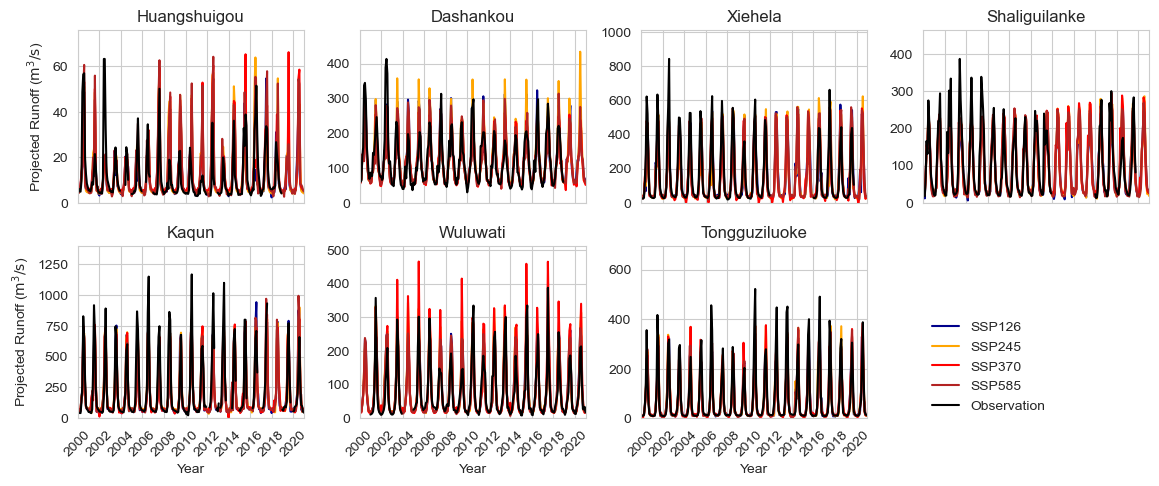

In [8]:
station_names = ['Huangshuigou', 'Dashankou', 'Xiehela', 'Shaliguilanke', 'Kaqun', 'Wuluwati', 'Tongguziluoke']

# Create a figure with 7 subplots
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(11.69, 8.27 * 0.6))  # Adjust figsize as needed
axes = axes.flatten()  # Flatten for easier indexing
# Remove the last unused subplot (if 7 subfigures)
fig.delaxes(axes[-1])

for i, file_name in enumerate(file_name_list):
    abbre = file_name.split('_')[1]
    ax = axes[i]  # Get the current subplot axis



    for j, scenario in enumerate(['ssp126', 'ssp245', 'ssp370', 'ssp585']):
        csv_mon_files = glob.glob(f'{file_name}*{scenario}*mon_256_16_project.csv')
        csv_mon_files = [item for item in csv_mon_files if 'multi-model' not in item]

        mon_df_list = [pd.read_csv(file, index_col=0) for file in csv_mon_files]
        for mon_df in mon_df_list:
            mon_df.index = pd.to_datetime(mon_df.index)
        total_mon_df = sum(mon_df_list) / len(station_names)

        ax.plot(
                mon_df.index,
            mon_df['Projected_Runoff'],
            label=['SSP126', 'SSP245', 'SSP370', 'SSP585'][j],
            color=colors[j],  # Set the color based on the scenario index
        )
    ax.plot(
        mon_df.index,
        mon_df['dis'],
        label='Observation',
        color='black'  # Set the color based on the scenario index
    )
    # # Customize the subplot
    ax.set_title(station_names[i])
    ax.set_xlim(pd.to_datetime("2000-01-01"), pd.to_datetime("2020-12-31"))
    ax.set_ylim(bottom =0, top = mon_df['dis'].max()*1.2)
    # ax.set_ylim(bottom = 0)
    ax.tick_params(axis='x', rotation=45)   # rotate by 45 degrees
    ax.set_xlabel('Year')
    ax.set_ylabel(r'Projected Runoff ($\mathrm{m^3/s}$)')
    # ax.legend(title='Scenarios', fontsize=8)
    ax.grid(True)

    # Remove y-axis labels for the 2nd column
    if i % 4 >0:  # Check for the 2nd column (odd index in a zero-based index system)
        ax.set_ylabel('')  # Remove the y-axis label

    # Remove x-axis labels and titles for all rows except the last row
    if i < len(axes) - 4:  # If the subplot is not in the last row (4 rows total, indices 0–5 for 7 plots)
        ax.set_xlabel('')  # Remove the x-axis label
        ax.set_xticklabels([])
    # ax.set_ylim(bottom = 0,top = 100)
    ax.set_facecolor('white')  # or 'none'



# Collect handles and labels for the legend
handles, labels = axes[0].get_legend_handles_labels()

# Remove legends from individual subplots
for ax in axes:
    ax.legend().remove()

# Add a single legend in the empty 8th subplot position
fig.legend(handles, labels, loc='center', fontsize='medium', frameon=False,
           bbox_to_anchor=(0.85, 0.25), bbox_transform=fig.transFigure)

# Adjust layout
plt.tight_layout()
plt.savefig(r'F:\geodata\river_runoff_obs\figure_ood_river_runoff.svg', facecolor='white')
plt.show()

hsg ssp245


<>:119: SyntaxWarning: invalid escape sequence '\m'
<>:119: SyntaxWarning: invalid escape sequence '\m'
C:\Users\HP\AppData\Local\Temp\ipykernel_154816\2306635077.py:119: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel('Projected Runoff ($\mathrm{m^3/s}$)')
C:\Users\HP\AppData\Local\Temp\ipykernel_154816\2306635077.py:119: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel('Projected Runoff ($\mathrm{m^3/s}$)')


NameError: name 'month_mapping' is not defined

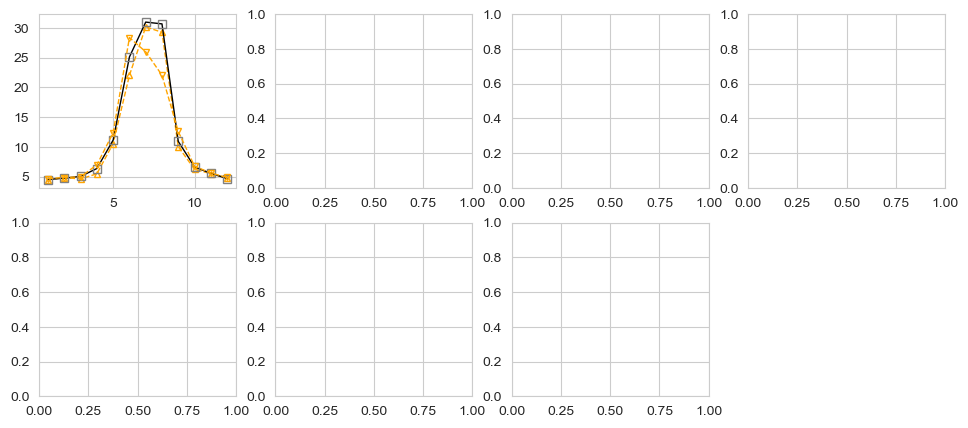

In [9]:
annual_mean_df['Projected_Runoff'][2005]
station_names = ['Huangshuigou', 'Dashankou', 'Xiehela', 'Shaliguilanke', 'Kaqun', 'Wuluwati', 'Tongguziluoke']

# Create a figure with 7 subplots
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(11.69, 8.27 * 0.6))  # Adjust figsize as needed
axes = axes.flatten()  # Flatten for easier indexing
# Remove the last unused subplot (if 7 subfigures)
fig.delaxes(axes[-1])

for i, file_name in enumerate(file_name_list):
    abbre = file_name.split('_')[1]
    ax = axes[i]  # Get the current subplot axis

    for j, scenario in enumerate(['ssp245', 'ssp585']):
        print(abbre, scenario)
        csv_mon_files = glob.glob(f'{file_name}*{scenario}*mon_256_16_project.csv')
        csv_mon_files = [item for item in csv_mon_files if 'multi-model' not in item]

        mon_df_list = [pd.read_csv(file, index_col=0) for file in csv_mon_files]
        for mon_df in mon_df_list:
            mon_df.index = pd.to_datetime(mon_df.index)
        annual_df_list = [df.resample('YE').mean() for df in mon_df_list]
        annaul_concatenated_df = pd.concat(annual_df_list, axis=0, keys=range(len(annual_df_list)))

        annual_std_dev = annaul_concatenated_df.groupby(level=1).std()

        # Concatenate DataFrames along a new axis and calculate standard deviation row-wise
        concatenated_df = pd.concat(mon_df_list, axis=0, keys=range(len(mon_df_list)))

        # Calculate standard deviation across the concatenated DataFrame
        std_dev_df = concatenated_df.groupby(level=1).std()
        std_dev_df.index = pd.to_datetime(std_dev_df.index)
        # Add a 'year' column for grouping
        std_dev_df['year'] = std_dev_df.index.year

        mean_df = concatenated_df.groupby(level=1).mean()
        mean_df.index = pd.to_datetime(mean_df.index)

        # if peak_water_df.loc[abbre,scenario] > 2055:
        #     continue

        # Split data into 3 periods
        before_peak_water_df = mean_df[mean_df.index.year <= float(peak_water_df.loc[abbre,scenario]) -15]
        after_peak_water_df  = mean_df[mean_df.index.year >  float(peak_water_df.loc[abbre,scenario]) +15]
        during_peak_water_df = mean_df[(mean_df.index.year > float(peak_water_df.loc[abbre, scenario]) - 15) &
                                       (mean_df.index.year <= float(peak_water_df.loc[abbre, scenario]) + 15)]

        before_peak_water_df = before_peak_water_df.copy()  # Make an explicit copy
        after_peak_water_df = after_peak_water_df.copy()  # Make an explicit copy
        during_peak_water_df = during_peak_water_df.copy() # Make an explicit copy

        before_peak_water_df.loc[:,'month'] = before_peak_water_df.index.month
        after_peak_water_df.loc[:, 'month'] = after_peak_water_df.index.month
        during_peak_water_df.loc[:,'month'] = during_peak_water_df.index.month

        before_mean_df = before_peak_water_df.groupby('month').mean()
        after_mean_df  = after_peak_water_df.groupby('month').mean()
        during_mean_df = during_peak_water_df.groupby('month').mean()

                # Plot the mean 'Projected_Runoff' for the current scenario with color
        ax.plot(
            before_mean_df.index,
            before_mean_df['Projected_Runoff'],
            label=f"{scenario.upper()}  (before)",
            color=colors[2*j +1],  # Set the color based on the scenario index
            marker='^',
            markerfacecolor='none',    # Set the face color to none for hollow effect
            linestyle='--',
            linewidth=1,
            markersize=5
        )

        if peak_water_df.loc[abbre,scenario]<2094:
            ax.plot(
                during_mean_df.index,
                during_mean_df['Projected_Runoff'],
                label=f"{scenario.upper()}  (during)",
                color='black',  # Set the color based on the scenario index
                marker="s",        # Use dots
                markerfacecolor='none',    # Set the face color to none for hollow effect
                markeredgecolor= 'grey' if scenario!='ssp585' else 'black',  # Set the color based on the scenario index
                linestyle='-',
                linewidth=1,
                markersize=6
            )
            ax.plot(
                after_mean_df.index,
                after_mean_df['Projected_Runoff'],
                label=f"{scenario.upper()}  (after)",
                color=colors[2*j +1],  # Set the color based on the scenario index
                marker='v',        # Use dots
                markerfacecolor='none',    # Set the face color to none for hollow effect
                linestyle='--',
                linewidth=1,
                markersize=5
            )

        # print(((during_mean_df['Projected_Runoff'][5:8] / before_mean_df['Projected_Runoff'])[5:8]).mean() -1)
        before_mean_df['Projected_Runoff'].index = before_mean_df['Projected_Runoff'].replace(month_mapping)
        during_mean_df['Projected_Runoff'].index = during_mean_df['Projected_Runoff'].replace(month_mapping)
        after_mean_df['Projected_Runoff'].index = after_mean_df['Projected_Runoff'].replace(month_mapping)

        before_center_of_mass = (before_mean_df.index.astype('int64') * before_mean_df['Projected_Runoff']).sum() / before_mean_df['Projected_Runoff'].sum()
        during_center_of_mass = (during_mean_df.index.astype('int64') * during_mean_df['Projected_Runoff']).sum() / during_mean_df['Projected_Runoff'].sum()
        after_center_of_mass = (after_mean_df.index.astype('int64') * after_mean_df['Projected_Runoff']).sum() / after_mean_df['Projected_Runoff'].sum()
        print(station_names[i],scenario,before_center_of_mass,during_center_of_mass,after_center_of_mass)


        # print(station_names[i],scenario,'before',((before_mean_df['Projected_Runoff'][5:8].sum() / before_mean_df['Projected_Runoff'].sum())) )
        # print(station_names[i],scenario,'during',((during_mean_df['Projected_Runoff'][5:8].sum() / during_mean_df['Projected_Runoff'].sum())) )
        # print(station_names[i],scenario,'after', ((after_mean_df['Projected_Runoff'][5:8].sum() / after_mean_df['Projected_Runoff'].sum())) )

        if i+j == 0:
            before_mean_df_sum = before_mean_df
            after_mean_df_sum = after_mean_df
        else:
            ax.set_xticks(before_mean_df.index)
    ax.set_title(abbre)
    ax.set_ylabel('Projected Runoff ($\mathrm{m^3/s}$)')
    ax.set_xlabel('Month')

    ax.set_title(station_names[i])  # Assign the corresponding title

    # Remove y-axis labels for the 2nd column
    if i % 4 >0:  # Check for the 2nd column (odd index in a zero-based index system)
        ax.set_ylabel('')  # Remove the y-axis label

    # Remove x-axis labels and titles for all rows except the last row
    if i < len(axes) - 4:  # If the subplot is not in the last row (4 rows total, indices 0–5 for 7 plots)
        ax.set_xlabel('')  # Remove the x-axis label
        ax.set_xticklabels([])
    else:
        ax.set_xlabel('Month')
    # ax.set_ylim(bottom = 0,top = 100)
    ax.set_facecolor('white')  # or 'none'


# Collect handles and labels for the legend
handles, labels = axes[0].get_legend_handles_labels()

# Remove legends from individual subplots
for ax in axes:
    ax.legend().remove()

# Add a single legend in the empty 8th subplot position
fig.legend(handles, labels, loc='center', fontsize='medium', frameon=False,
           bbox_to_anchor=(0.85, 0.25), bbox_transform=fig.transFigure)


plt.tight_layout()
plt.savefig(r'F:\geodata\river_runoff_obs\figures\figure2_1_SSP245_SSP585.svg')
plt.show()

In [81]:
before_mean_df['Projected_Runoff'].index = before_mean_df['Projected_Runoff'].replace(month_mapping)

In [82]:
during_mean_df['Projected_Runoff'][6:8]

C:\Users\HP\AppData\Local\Temp\ipykernel_8696\803588679.py:1: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  during_mean_df['Projected_Runoff'][6:8]


KeyError: 6

<>:105: SyntaxWarning: invalid escape sequence '\m'
<>:105: SyntaxWarning: invalid escape sequence '\m'
C:\Users\HP\AppData\Local\Temp\ipykernel_154816\559945097.py:105: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel('Projected Runoff ($\mathrm{m^3/s}$)')


hsg ssp126
Huangshuigou ssp126 before 0.5796245272889889
Huangshuigou ssp126 during 0.5838741465280239
Huangshuigou ssp126 after 0.5489669072698435
hsg ssp245
Huangshuigou ssp245 before 0.5908443940452357
Huangshuigou ssp245 during 0.5928348559511336
Huangshuigou ssp245 after 0.5455321094886693
hsg ssp370
Huangshuigou ssp370 before 0.5816400369880355
Huangshuigou ssp370 during 0.5929423145591179
Huangshuigou ssp370 after 0.5341593591364088
hsg ssp585
Huangshuigou ssp585 before 0.5869126422439077
Huangshuigou ssp585 during 0.5948867496182642
Huangshuigou ssp585 after 0.5358710582913369
dsk ssp126
Dashankou ssp126 before 0.44171429699241505
Dashankou ssp126 during 0.4425135967110111
Dashankou ssp126 after 0.4294522311752928
dsk ssp245
Dashankou ssp245 before 0.4359718323698864
Dashankou ssp245 during 0.4436387317576605
Dashankou ssp245 after 0.4150246965832513
dsk ssp370
Dashankou ssp370 before 0.4369204299840943
Dashankou ssp370 during 0.44600376981575723
Dashankou ssp370 after 0.408869

C:\Users\HP\AppData\Local\Temp\ipykernel_154816\559945097.py:96: RuntimeWarning: invalid value encountered in scalar divide
  print(station_names[i],scenario,'after', ((after_mean_df['Projected_Runoff'][5:8].sum() / after_mean_df['Projected_Runoff'].sum())) )
C:\Users\HP\AppData\Local\Temp\ipykernel_154816\559945097.py:96: RuntimeWarning: invalid value encountered in scalar divide
  print(station_names[i],scenario,'after', ((after_mean_df['Projected_Runoff'][5:8].sum() / after_mean_df['Projected_Runoff'].sum())) )


Tongguziluoke ssp245 before 0.7681168179657197
Tongguziluoke ssp245 during 0.8089494138928199
Tongguziluoke ssp245 after 0.804792076979433
tgzlk ssp370
Tongguziluoke ssp370 before 0.7761337566152798
Tongguziluoke ssp370 during 0.8226669170126815
Tongguziluoke ssp370 after nan
tgzlk ssp585
Tongguziluoke ssp585 before 0.7986082926880744
Tongguziluoke ssp585 during 0.8226123428987976
Tongguziluoke ssp585 after nan


C:\Users\HP\AppData\Local\Temp\ipykernel_154816\559945097.py:96: RuntimeWarning: invalid value encountered in scalar divide
  print(station_names[i],scenario,'after', ((after_mean_df['Projected_Runoff'][5:8].sum() / after_mean_df['Projected_Runoff'].sum())) )
C:\Users\HP\AppData\Local\Temp\ipykernel_154816\559945097.py:125: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


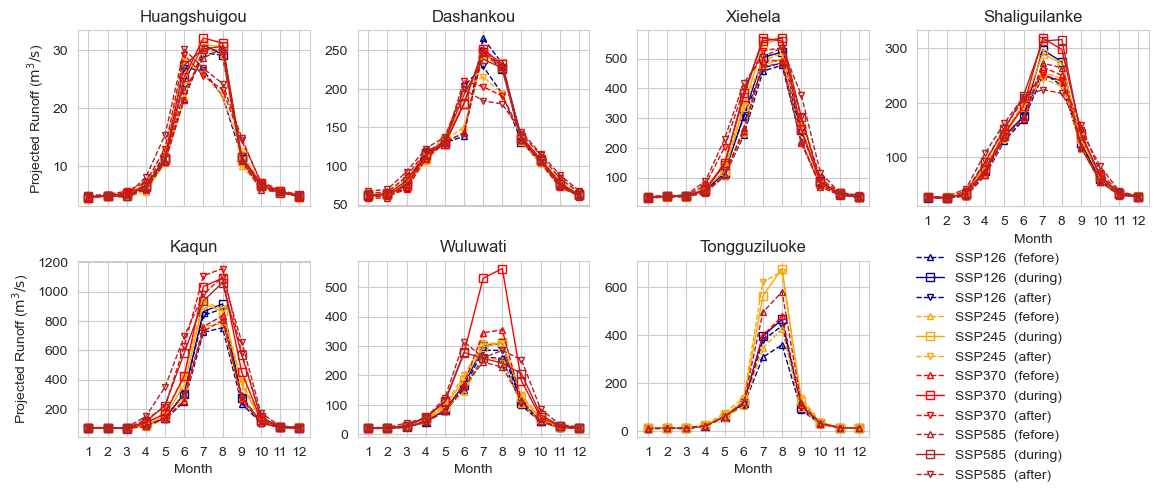

In [10]:
station_names = ['Huangshuigou', 'Dashankou', 'Xiehela', 'Shaliguilanke', 'Kaqun', 'Wuluwati', 'Tongguziluoke']

# Create a figure with 7 subplots
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(11.69, 8.27 * 0.6))  # Adjust figsize as needed
axes = axes.flatten()  # Flatten for easier indexing
# Remove the last unused subplot (if 7 subfigures)
fig.delaxes(axes[-1])

for i, file_name in enumerate(file_name_list):
    abbre = file_name.split('_')[1]
    ax = axes[i]  # Get the current subplot axis

    for j, scenario in enumerate(['ssp126', 'ssp245', 'ssp370', 'ssp585']):
        print(abbre, scenario)
        csv_mon_files = glob.glob(f'{file_name}*{scenario}*mon*_project.csv')
        csv_mon_files = [item for item in csv_mon_files if 'multi-model' not in item]

        mon_df_list = [pd.read_csv(file, index_col=0) for file in csv_mon_files]
        for mon_df in mon_df_list:
            mon_df.index = pd.to_datetime(mon_df.index)
        annual_df_list = [df.resample('YE').mean() for df in mon_df_list]
        annaul_concatenated_df = pd.concat(annual_df_list, axis=0, keys=range(len(annual_df_list)))

        annual_std_dev = annaul_concatenated_df.groupby(level=1).std()

        # Concatenate DataFrames along a new axis and calculate standard deviation row-wise
        concatenated_df = pd.concat(mon_df_list, axis=0, keys=range(len(mon_df_list)))

        # Calculate standard deviation across the concatenated DataFrame
        std_dev_df = concatenated_df.groupby(level=1).std()
        std_dev_df.index = pd.to_datetime(std_dev_df.index)
        # Add a 'year' column for grouping
        std_dev_df['year'] = std_dev_df.index.year

        mean_df = concatenated_df.groupby(level=1).mean()
        mean_df.index = pd.to_datetime(mean_df.index)

        # Split data into 3 periods
        before_peak_water_df = mean_df[mean_df.index.year <= float(peak_water_df.loc[abbre,scenario]) -15]
        after_peak_water_df  = mean_df[mean_df.index.year >  float(peak_water_df.loc[abbre,scenario]) +15]
        during_peak_water_df = mean_df[(mean_df.index.year > float(peak_water_df.loc[abbre, scenario]) - 15) &
                                       (mean_df.index.year <= float(peak_water_df.loc[abbre, scenario]) + 15)]

        before_peak_water_df = before_peak_water_df.copy()  # Make an explicit copy
        after_peak_water_df = after_peak_water_df.copy()  # Make an explicit copy
        during_peak_water_df = during_peak_water_df.copy() # Make an explicit copy

        before_peak_water_df.loc[:,'month'] = before_peak_water_df.index.month
        after_peak_water_df.loc[:, 'month'] = after_peak_water_df.index.month
        during_peak_water_df.loc[:,'month'] = during_peak_water_df.index.month

        before_mean_df = before_peak_water_df.groupby('month').mean()
        after_mean_df  = after_peak_water_df.groupby('month').mean()
        during_mean_df = during_peak_water_df.groupby('month').mean()

                # Plot the mean 'Projected_Runoff' for the current scenario with color
        ax.plot(
            before_mean_df.index,
            before_mean_df['Projected_Runoff'],
            label=f"{scenario.upper()}  (fefore)",
            color=colors[j],  # Set the color based on the scenario index
            marker='^',
            markerfacecolor='none',    # Set the face color to none for hollow effect
            linestyle='--',
            linewidth=1,
            markersize=5
        )

        if peak_water_df.loc[abbre,scenario]<2094:

            ax.plot(
                during_mean_df.index,
                during_mean_df['Projected_Runoff'],
                label=f"{scenario.upper()}  (during)",
                color=colors[j],  # Set the color based on the scenario index
                marker="s",        # Use dots
                markerfacecolor='none',    # Set the face color to none for hollow effect
                linestyle='-',
                linewidth=1,
                markersize=6
            )
            ax.plot(
                after_mean_df.index,
                after_mean_df['Projected_Runoff'],
                label=f"{scenario.upper()}  (after)",
                color=colors[j],  # Set the color based on the scenario index
                marker='v',        # Use dots
                markerfacecolor='none',    # Set the face color to none for hollow effect
                linestyle='--',
                linewidth=1,
                markersize=5
            )
        # print(((during_mean_df['Projected_Runoff'][4:9] / before_mean_df['Projected_Runoff'])[4:9]).mean() -1)
        print(station_names[i],scenario,'before',((before_mean_df['Projected_Runoff'][5:8].sum() / before_mean_df['Projected_Runoff'].sum())) )
        print(station_names[i],scenario,'during',((during_mean_df['Projected_Runoff'][5:8].sum() / during_mean_df['Projected_Runoff'].sum())) )
        print(station_names[i],scenario,'after', ((after_mean_df['Projected_Runoff'][5:8].sum() / after_mean_df['Projected_Runoff'].sum())) )

        if i+j == 0:
            before_mean_df_sum = before_mean_df
            after_mean_df_sum = after_mean_df
        else:

            ax.set_xticks(before_mean_df.index)
    ax.set_title(abbre)
    ax.set_ylabel('Projected Runoff ($\mathrm{m^3/s}$)')
    ax.set_xlabel('Month')

    ax.set_title(station_names[i])  # Assign the corresponding title

    # Remove y-axis labels for the 2nd column
    if i % 4 >0:  # Check for the 2nd column (odd index in a zero-based index system)
        ax.set_ylabel('')  # Remove the y-axis label

    # Remove x-axis labels and titles for all rows except the last row
    if i < len(axes) - 5:  # If the subplot is not in the last row (4 rows total, indices 0–5 for 7 plots)
        ax.set_xlabel('')  # Remove the x-axis label
        ax.set_xticklabels([])
    # ax.set_ylim(bottom = 0,top = 100)

# Collect handles and labels for the legend
handles, labels = axes[0].get_legend_handles_labels()

# Remove legends from individual subplots
for ax in axes:
    ax.legend().remove()

# Add a single legend in the empty 8th subplot position
fig.legend(handles, labels, loc='center', fontsize='medium', frameon=False,
           bbox_to_anchor=(0.85, 0.25), bbox_transform=fig.transFigure)


plt.tight_layout()
plt.savefig(r'F:\geodata\river_runoff_obs\figures\figure2_1.svg')
plt.show()

In [11]:
2360-1084/2

1818.0

hsg ssp126
month
5    0.094962
6    0.074130
7    0.043532
8    0.012270
9   -0.076250
Name: pre, dtype: float64
hsg ssp245
month
5    0.093762
6    0.043120
7   -0.038525
8   -0.017983
9   -0.106411
Name: pre, dtype: float64
hsg ssp370
month
5    0.040842
6    0.036507
7    0.015618
8    0.048075
9   -0.062839
Name: pre, dtype: float64
hsg ssp585
month
5    0.113925
6    0.044451
7    0.012233
8    0.027958
9    0.005788
Name: pre, dtype: float64
dsk ssp126
month
5    0.045709
6    0.009597
7    0.046632
8    0.039842
9   -0.017071
Name: pre, dtype: float64
dsk ssp245
month
5    0.049023
6    0.027539
7   -0.005943
8   -0.023935
9   -0.046856
Name: pre, dtype: float64
dsk ssp370
month
5    0.011302
6    0.035963
7   -0.012777
8    0.043882
9   -0.018997
Name: pre, dtype: float64
dsk ssp585
month
5    0.035641
6    0.003200
7   -0.009953
8    0.003182
9   -0.019833
Name: pre, dtype: float64
xhl ssp126
month
5    0.039754
6   -0.004056
7    0.021749
8    0.039320
9    0.027289
Name: pre

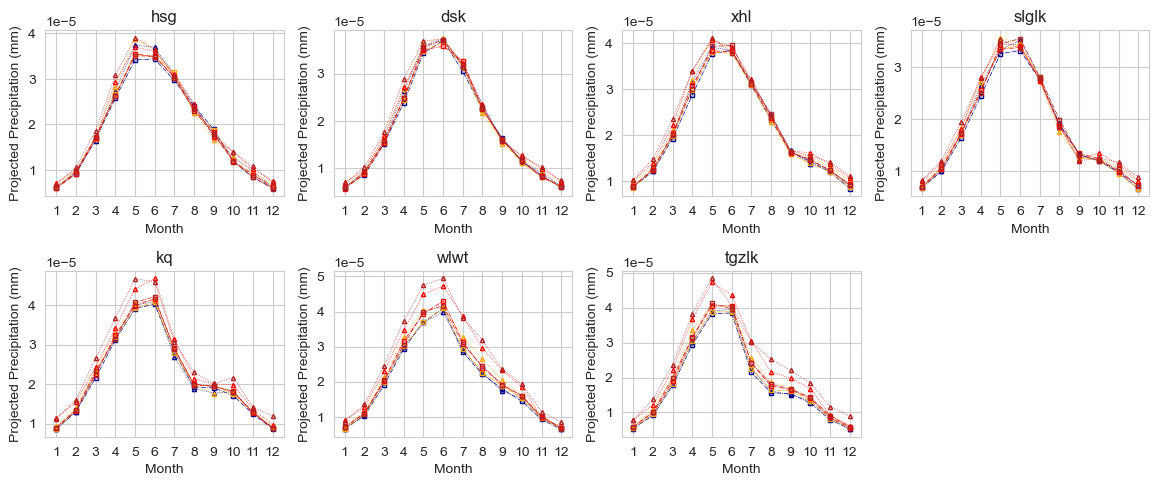

In [12]:
# Create a figure with 7 subplots
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(11.69, 8.27 * 0.6))  # Adjust figsize as needed
axes = axes.flatten()  # Flatten for easier indexing
# Remove the last unused subplot (if 7 subfigures)
fig.delaxes(axes[-1])

for i, file_name in enumerate(file_name_list):
    abbre = file_name.split('_')[1]
    ax = axes[i]  # Get the current subplot axis

    for j, scenario in enumerate(['ssp126', 'ssp245', 'ssp370', 'ssp585']):
        print(abbre, scenario)
        csv_mon_files = glob.glob(f'{file_name}*{scenario}*mon*_project.csv')
        csv_mon_files = [item for item in csv_mon_files if 'multi-model' not in item]

        mon_df_list = [pd.read_csv(file, index_col=0) for file in csv_mon_files]
        for mon_df in mon_df_list:
            mon_df.index = pd.to_datetime(mon_df.index)
        annual_df_list = [df.resample('YE').mean() for df in mon_df_list]
        annaul_concatenated_df = pd.concat(annual_df_list, axis=0, keys=range(len(annual_df_list)))

        annual_std_dev = annaul_concatenated_df.groupby(level=1).std()

        # Concatenate DataFrames along a new axis and calculate standard deviation row-wise
        concatenated_df = pd.concat(mon_df_list, axis=0, keys=range(len(mon_df_list)))

        # Calculate standard deviation across the concatenated DataFrame
        std_dev_df = concatenated_df.groupby(level=1).std()
        std_dev_df.index = pd.to_datetime(std_dev_df.index)
        # Add a 'year' column for grouping
        std_dev_df['year'] = std_dev_df.index.year

        mean_df = concatenated_df.groupby(level=1).mean()
        mean_df.index = pd.to_datetime(mean_df.index)

        # Split data into two periods
        before_peak_water_df = mean_df[mean_df.index.year <= float(peak_water_df.loc[abbre,scenario])]
        after_peak_water_df  = mean_df[mean_df.index.year >  float(peak_water_df.loc[abbre,scenario])]

        before_peak_water_df = before_peak_water_df.copy()  # Make an explicit copy
        after_peak_water_df = after_peak_water_df.copy()  # Make an explicit copy

        before_peak_water_df.loc[:,'month'] = before_peak_water_df.index.month
        after_peak_water_df.loc[:, 'month'] = after_peak_water_df.index.month

        before_mean_df = before_peak_water_df.groupby('month').mean()
        after_mean_df  = after_peak_water_df.groupby('month').mean()

                # Plot the mean 'Projected_Runoff' for the current scenario with color
        ax.plot(
            before_mean_df.index,
            before_mean_df['pre'],
            label=scenario,
            color=colors[j],  # Set the color based on the scenario index
            marker='s',
            markerfacecolor='none',    # Set the face color to none for hollow effect
            linestyle='dashdot',
            linewidth=0.5,
            markersize=3
        )
        ax.plot(
            after_mean_df.index,
            after_mean_df['pre'],
            label=scenario,
            color=colors[j],  # Set the color based on the scenario index
            marker='^',        # Use dots
            markerfacecolor='none',    # Set the face color to none for hollow effect
            linestyle='dotted',
            linewidth=0.5,
            markersize=3
        )
        print((after_mean_df['pre'][4:9] / before_mean_df['pre'])[4:9] -1)

        if i+j == 0:
            before_mean_df_sum = before_mean_df
            after_mean_df_sum = after_mean_df
        else:

            ax.set_xticks(before_mean_df.index)
    ax.set_title(abbre)
    ax.set_ylabel('Projected Precipitation (mm)')
    ax.set_xlabel('Month')

    # ax.set_ylim(bottom = 0,top = 100)
# plt.legend(title='Scenarios', fontsize=8)
plt.tight_layout()
plt.savefig(r'F:\geodata\river_runoff_obs\figures\figure2_1_precipitation.svg')
plt.show()

In [13]:
mean_df

,dis,tm,pre,ep,gr,Projected_Runoff,Projected_Evaporation
time,,,,,,,
2000-01-01,11.019677,257.490608,0.000005,17.158710,0.000000e+00,8.770550,21.271074
2000-02-01,9.846207,260.793586,0.000008,30.532414,0.000000e+00,10.332288,29.454944
2000-03-01,10.148387,265.189470,0.000018,54.243871,0.000000e+00,12.860347,53.966570
2000-04-01,13.583333,270.871727,0.000028,90.959333,0.000000e+00,16.998093,89.519189
2000-05-01,52.506452,277.026571,0.000035,132.774194,9.649225e+03,54.562480,132.122967
...,...,...,...,...,...,...,...
2100-08-01,NaN,285.377370,0.000026,NaN,5.422960e+09,1296.691890,532.690316
2100-09-01,NaN,281.158253,0.000022,NaN,1.317148e+09,471.474447,215.813170
2100-10-01,NaN,275.915880,0.000014,NaN,7.268503e+06,76.584244,117.557887


hsg ssp126
1.0311901593781883
hsg ssp245
1.0345413457436878
hsg ssp370
1.0572117976196573
hsg ssp585
1.0364922707373145
dsk ssp126


<>:71: SyntaxWarning: invalid escape sequence '\m'
<>:71: SyntaxWarning: invalid escape sequence '\m'
C:\Users\HP\AppData\Local\Temp\ipykernel_154816\3929095789.py:71: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel('Projected Runoff ($\mathrm{m^3/s}$)')


1.030964348496828
dsk ssp245
1.0509562847632736
dsk ssp370
1.0580467413526262
dsk ssp585
1.108234673041992
xhl ssp126
1.0317884387731893
xhl ssp245
1.062853040629337
xhl ssp370
1.1245325989152255
xhl ssp585
1.0735132228024582
slglk ssp126
1.0032050934512895
slglk ssp245
1.0128922485060359
slglk ssp370
1.0206684370067538
slglk ssp585
1.0302741755401492
kq ssp126
1.014778170681319
kq ssp245
1.0214675676543916
kq ssp370
1.0030803727629511
kq ssp585
1.0119554614369728
wlwt ssp126
1.0104359584857054
wlwt ssp245
1.0290952505941402
wlwt ssp370
1.0572785871325276
wlwt ssp585
1.106030822471618
tgzlk ssp126
1.010217131134196
tgzlk ssp245
1.0548499709257688
tgzlk ssp370
1.110366422696982
tgzlk ssp585
1.2233727347743228


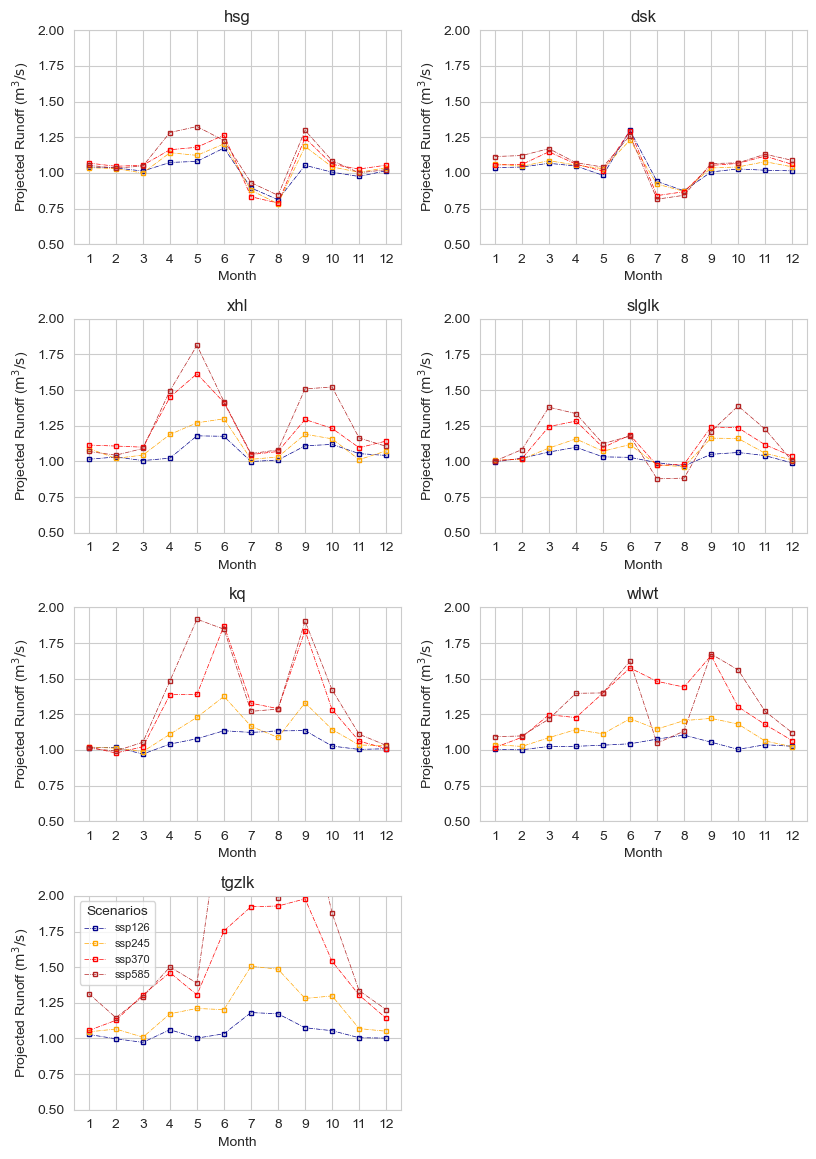

In [14]:
# Create a figure with 7 subplots
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=( 8.27 , 11.69))  # Adjust figsize as needed
axes = axes.flatten()  # Flatten for easier indexing
# Remove the last unused subplot (if 7 subfigures)
fig.delaxes(axes[-1])

for i, file_name in enumerate(file_name_list):
    abbre = file_name.split('_')[1]
    ax = axes[i]  # Get the current subplot axis

    for j, scenario in enumerate(['ssp126', 'ssp245', 'ssp370', 'ssp585']):
        print(abbre, scenario)
        csv_mon_files = glob.glob(f'{file_name}*{scenario}*mon*_project.csv')
        csv_mon_files = [item for item in csv_mon_files if 'multi-model' not in item]

        mon_df_list = [pd.read_csv(file, index_col=0) for file in csv_mon_files]
        for mon_df in mon_df_list:
            mon_df.index = pd.to_datetime(mon_df.index)
        annual_df_list = [df.resample('YE').mean() for df in mon_df_list]
        annaul_concatenated_df = pd.concat(annual_df_list, axis=0, keys=range(len(annual_df_list)))

        annual_std_dev = annaul_concatenated_df.groupby(level=1).std()

        # Concatenate DataFrames along a new axis and calculate standard deviation row-wise
        concatenated_df = pd.concat(mon_df_list, axis=0, keys=range(len(mon_df_list)))

        # Calculate standard deviation across the concatenated DataFrame
        std_dev_df = concatenated_df.groupby(level=1).std()
        std_dev_df.index = pd.to_datetime(std_dev_df.index)
        # Add a 'year' column for grouping
        std_dev_df['year'] = std_dev_df.index.year

        mean_df = concatenated_df.groupby(level=1).mean()
        mean_df.index = pd.to_datetime(mean_df.index)

        # Split data into two periods
        before_peak_water_df = mean_df[mean_df.index.year <= float(peak_water_df.loc[abbre,scenario])]
        after_peak_water_df  = mean_df[mean_df.index.year >  float(peak_water_df.loc[abbre,scenario])]

        before_peak_water_df = before_peak_water_df.copy()  # Make an explicit copy
        after_peak_water_df = after_peak_water_df.copy()  # Make an explicit copy

        before_peak_water_df.loc[:,'month'] = before_peak_water_df.index.month
        after_peak_water_df.loc[:, 'month'] = after_peak_water_df.index.month

        before_mean_df = before_peak_water_df.groupby('month').mean()
        after_mean_df  = after_peak_water_df.groupby('month').mean()

                # Plot the mean 'Projected_Runoff' for the current scenario with color
        ax.plot(
            before_mean_df.index,
            after_mean_df['Projected_Runoff']/before_mean_df['Projected_Runoff'],
            label=scenario,
            color=colors[j],  # Set the color based on the scenario index
            marker='s',
            markerfacecolor='none',    # Set the face color to none for hollow effect
            linestyle='dashdot',
            linewidth=0.5,
            markersize=3
        )

        print((after_mean_df['Projected_Runoff'][[12,1,2]].mean() / before_mean_df['Projected_Runoff'])[[12,1,2]].mean())

        if i+j == 0:
            before_mean_df_sum = before_mean_df
            after_mean_df_sum = after_mean_df
        else:

            ax.set_xticks(before_mean_df.index)
    ax.set_title(abbre)
    ax.set_ylabel('Projected Runoff ($\mathrm{m^3/s}$)')
    ax.set_xlabel('Month')

    ax.set_ylim(bottom = 0.5,top = 2)
plt.legend(title='Scenarios', fontsize=8)
plt.tight_layout()
plt.show()

hsg ssp126
1.0624034830958329
hsg ssp245
1.098145569498185
hsg ssp370
1.1981794685984093
hsg ssp585
1.2034618250428635
dsk ssp126
1.0726158220327877
dsk ssp245
1.1257008366293852
dsk ssp370
1.1909146072279888
dsk ssp585
1.2142749160098762
xhl ssp126
1.0547118018076143
xhl ssp245
1.1453066317024547
xhl ssp370
1.1621195667749986
xhl ssp585
1.214136003590295
slglk ssp126
1.0691764184618144
slglk ssp245
1.149658366952147
slglk ssp370
1.160356993519694
slglk ssp585
1.218045071612208
kq ssp126
1.0449042400286
kq ssp245
1.092448008373947
kq ssp370
1.2183303068662652
kq ssp585
1.2962506847309156
wlwt ssp126
1.0664870915107683
wlwt ssp245
1.1219700939562045
wlwt ssp370
1.2133926441322587
wlwt ssp585
1.2929081901767365
tgzlk ssp126
1.066589558964498
tgzlk ssp245
1.173546466579394
tgzlk ssp370
1.2946465546940322
tgzlk ssp585
1.4906598456548845


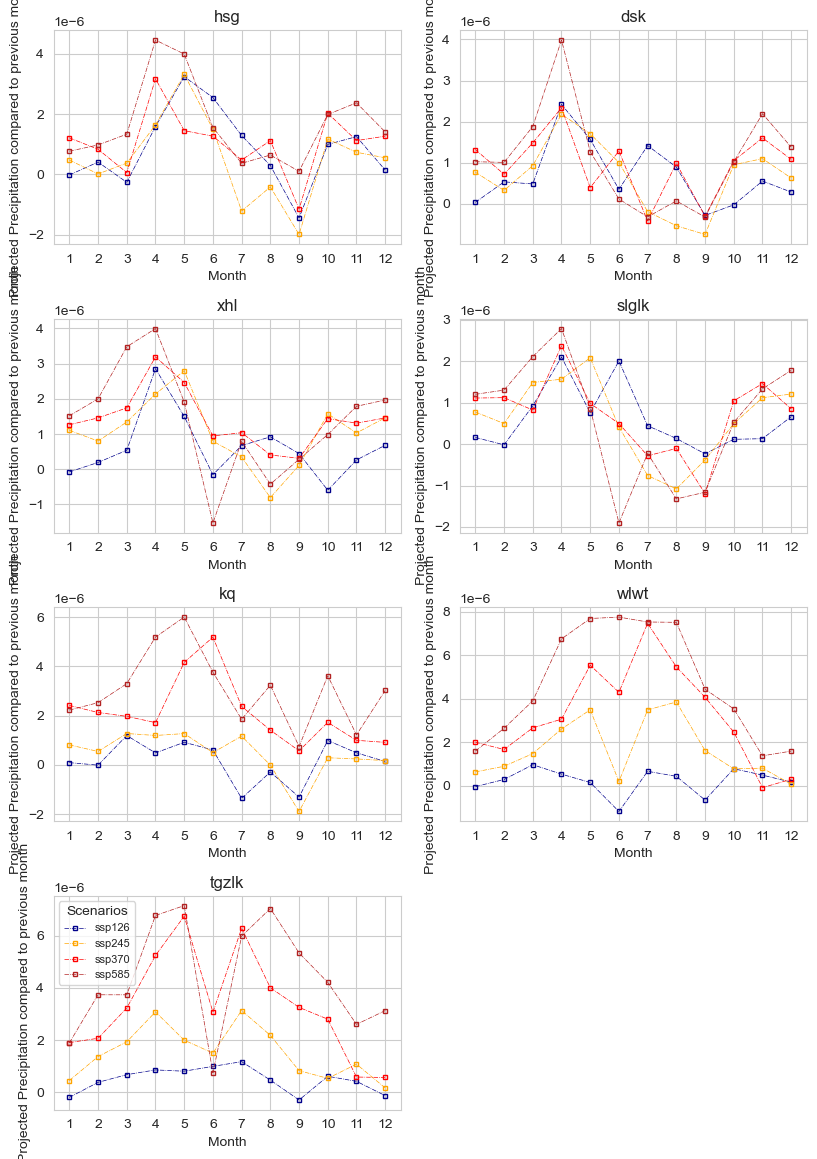

In [15]:
# Create a figure with 7 subplots
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=( 8.27 , 11.69))  # Adjust figsize as needed
axes = axes.flatten()  # Flatten for easier indexing
# Remove the last unused subplot (if 7 subfigures)
fig.delaxes(axes[-1])

for i, file_name in enumerate(file_name_list):
    abbre = file_name.split('_')[1]
    ax = axes[i]  # Get the current subplot axis

    for j, scenario in enumerate(['ssp126', 'ssp245', 'ssp370', 'ssp585']):
        print(abbre, scenario)
        csv_mon_files = glob.glob(f'{file_name}*{scenario}*mon*_project.csv')
        csv_mon_files = [item for item in csv_mon_files if 'multi-model' not in item]

        mon_df_list = [pd.read_csv(file, index_col=0) for file in csv_mon_files]
        for mon_df in mon_df_list:
            mon_df.index = pd.to_datetime(mon_df.index)
        annual_df_list = [df.resample('YE').mean() for df in mon_df_list]
        annaul_concatenated_df = pd.concat(annual_df_list, axis=0, keys=range(len(annual_df_list)))

        annual_std_dev = annaul_concatenated_df.groupby(level=1).std()

        # Concatenate DataFrames along a new axis and calculate standard deviation row-wise
        concatenated_df = pd.concat(mon_df_list, axis=0, keys=range(len(mon_df_list)))

        # Calculate standard deviation across the concatenated DataFrame
        std_dev_df = concatenated_df.groupby(level=1).std()
        std_dev_df.index = pd.to_datetime(std_dev_df.index)
        # Add a 'year' column for grouping
        std_dev_df['year'] = std_dev_df.index.year

        mean_df = concatenated_df.groupby(level=1).mean()
        mean_df.index = pd.to_datetime(mean_df.index)

        # Split data into two periods
        before_peak_water_df = mean_df[mean_df.index.year <= float(peak_water_df.loc[abbre,scenario])]
        after_peak_water_df  = mean_df[mean_df.index.year >  float(peak_water_df.loc[abbre,scenario])]

        before_peak_water_df = before_peak_water_df.copy()  # Make an explicit copy
        after_peak_water_df = after_peak_water_df.copy()  # Make an explicit copy

        before_peak_water_df.loc[:,'month'] = before_peak_water_df.index.month
        after_peak_water_df.loc[:, 'month'] = after_peak_water_df.index.month

        before_mean_df = before_peak_water_df.groupby('month').mean()
        after_mean_df  = after_peak_water_df.groupby('month').mean()

                # Plot the mean 'pre' for the current scenario with color
        ax.plot(
            before_mean_df.index,
            after_mean_df['pre']-before_mean_df['pre'],
            label=scenario,
            color=colors[j],  # Set the color based on the scenario index
            marker='s',
            markerfacecolor='none',    # Set the face color to none for hollow effect
            linestyle='dashdot',
            linewidth=0.5,
            markersize=3
        )

        print((after_mean_df['pre'][[12,1,2]].mean() / before_mean_df['pre'])[[12,1,2]].mean())

        if i+j == 0:
            before_mean_df_sum = before_mean_df
            after_mean_df_sum = after_mean_df
        else:

            ax.set_xticks(before_mean_df.index)
    ax.set_title(abbre)
    ax.set_ylabel('Projected Precipitation compared to previous month')
    ax.set_xlabel('Month')

    # ax.set_ylim(bottom = 0.5,top = 2)
plt.legend(title='Scenarios', fontsize=8)
plt.tight_layout()
plt.show()

hsg ssp126
0.8376798921056169
hsg ssp245
1.1626492426018444
hsg ssp370
1.636002317838404
hsg ssp585
2.045555808736424
dsk ssp126
0.9324753441646673
dsk ssp245
1.4360725609762046
dsk ssp370
1.9798352469223535
dsk ssp585
2.4895750485766825
xhl ssp126
0.6150013872064429
xhl ssp245
1.3255095068545302
xhl ssp370
2.0096954002757648
xhl ssp585
2.704153746517098
slglk ssp126
0.6235923795749159
slglk ssp245
1.2688484508425784
slglk ssp370
1.9234447037689886
slglk ssp585
2.584008203412774
kq ssp126
0.3835214506661468
kq ssp245
1.3059599031204243
kq ssp370
2.332381451333996
kq ssp585
2.9583968799929607
wlwt ssp126
0.33269189671561133
wlwt ssp245
1.3261713675868425
wlwt ssp370
3.023259757478703
wlwt ssp585
3.2443757836248985
tgzlk ssp126
0.38793876331362753
tgzlk ssp245
1.6037426477091685
tgzlk ssp370
3.155036486107633
tgzlk ssp585
3.665675215561199


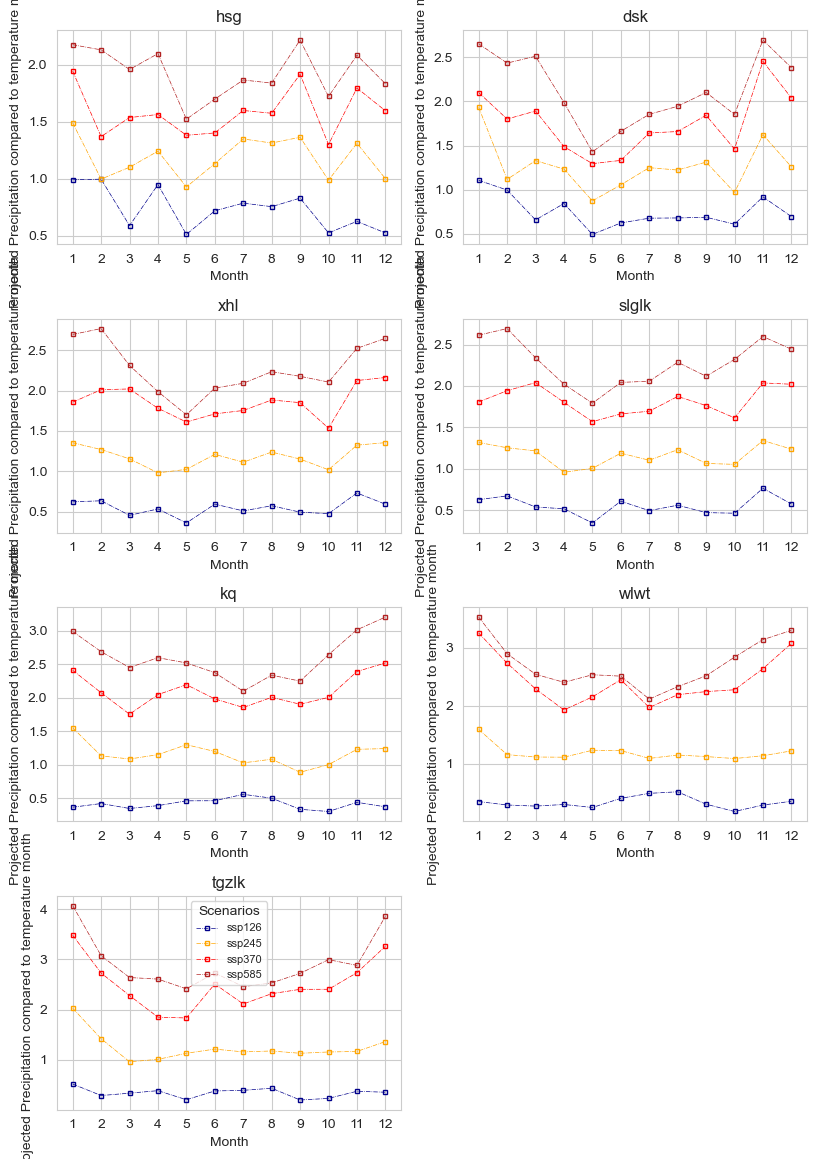

In [16]:
# Create a figure with 7 subplots
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=( 8.27 , 11.69))  # Adjust figsize as needed
axes = axes.flatten()  # Flatten for easier indexing
# Remove the last unused subplot (if 7 subfigures)
fig.delaxes(axes[-1])

for i, file_name in enumerate(file_name_list):
    abbre = file_name.split('_')[1]
    ax = axes[i]  # Get the current subplot axis

    for j, scenario in enumerate(['ssp126', 'ssp245', 'ssp370', 'ssp585']):
        print(abbre, scenario)
        csv_mon_files = glob.glob(f'{file_name}*{scenario}*mon*_project.csv')
        csv_mon_files = [item for item in csv_mon_files if 'multi-model' not in item]

        mon_df_list = [pd.read_csv(file, index_col=0) for file in csv_mon_files]
        for mon_df in mon_df_list:
            mon_df.index = pd.to_datetime(mon_df.index)
        annual_df_list = [df.resample('YE').mean() for df in mon_df_list]
        annaul_concatenated_df = pd.concat(annual_df_list, axis=0, keys=range(len(annual_df_list)))

        annual_std_dev = annaul_concatenated_df.groupby(level=1).std()

        # Concatenate DataFrames along a new axis and calculate standard deviation row-wise
        concatenated_df = pd.concat(mon_df_list, axis=0, keys=range(len(mon_df_list)))

        # Calculate standard deviation across the concatenated DataFrame
        std_dev_df = concatenated_df.groupby(level=1).std()
        std_dev_df.index = pd.to_datetime(std_dev_df.index)
        # Add a 'year' column for grouping
        std_dev_df['year'] = std_dev_df.index.year

        mean_df = concatenated_df.groupby(level=1).mean()
        mean_df.index = pd.to_datetime(mean_df.index)

        # Split data into two periods
        before_peak_water_df = mean_df[mean_df.index.year <= float(peak_water_df.loc[abbre,scenario])]
        after_peak_water_df  = mean_df[mean_df.index.year >  float(peak_water_df.loc[abbre,scenario])]

        before_peak_water_df = before_peak_water_df.copy()  # Make an explicit copy
        after_peak_water_df = after_peak_water_df.copy()  # Make an explicit copy

        before_peak_water_df.loc[:,'month'] = before_peak_water_df.index.month
        after_peak_water_df.loc[:, 'month'] = after_peak_water_df.index.month

        before_mean_df = before_peak_water_df.groupby('month').mean()
        after_mean_df  = after_peak_water_df.groupby('month').mean()

                # Plot the mean 'tm' for the current scenario with color
        ax.plot(
            before_mean_df.index,
            after_mean_df['tm']-before_mean_df['tm'],
            label=scenario,
            color=colors[j],  # Set the color based on the scenario index
            marker='s',
            markerfacecolor='none',    # Set the face color to none for hollow effect
            linestyle='dashdot',
            linewidth=0.5,
            markersize=3
        )

        print((after_mean_df['tm'][[12,1,2]].mean() - before_mean_df['tm'])[[12,1,2]].mean())

        if i+j == 0:
            before_mean_df_sum = before_mean_df
            after_mean_df_sum = after_mean_df
        else:

            ax.set_xticks(before_mean_df.index)
    ax.set_title(abbre)
    ax.set_ylabel('Projected Precipitation compared to temperature month')
    ax.set_xlabel('Month')

    # ax.set_ylim(bottom = 0.5,top = 2)
plt.legend(title='Scenarios', fontsize=8)
plt.tight_layout()
plt.show()

In [17]:
(after_mean_df['Projected_Runoff'] / before_mean_df['Projected_Runoff'])[4:9].mean()

np.float64(2.1831831996250446)

In [18]:
before_mean_df

,dis,tm,pre,ep,gr,Projected_Runoff,Projected_Evaporation
month,,,,,,,
1,11.985318,261.010658,0.000006,17.895520,0.000000e+00,11.110770,26.069475
2,11.140892,263.411499,0.000010,37.536535,8.767900e+00,13.119588,35.442903
3,11.072785,267.524808,0.000020,59.342492,1.594645e+04,15.732879,62.813455
4,15.279273,272.277856,0.000032,93.748995,2.275675e+05,24.437047,100.285652
5,36.632851,277.956293,0.000041,137.725474,2.822317e+06,64.526101,144.405753
6,110.610674,282.551663,0.000040,173.414356,1.324108e+08,138.513620,173.098953
7,310.342486,284.584927,0.000024,176.585626,1.903163e+09,587.174498,275.931644
8,334.450830,283.011155,0.000018,162.166144,2.425101e+09,682.888915,303.946636
9,94.728054,278.054254,0.000017,120.223721,1.515769e+08,142.362363,140.777031
